# Complete Photonic Cavity Analysis Workflow

This notebook provides a comprehensive, well-organized analysis workflow for photonic cavities using Tidy3D simulations. The workflow includes all analysis modules in a logical, sequential order with proper documentation and error handling.

## Analysis Pipeline Overview

1. **Setup & Configuration** - Import modules and set analysis parameters
2. **Simulation Setup** - Create geometry, materials, sources, and monitors
3. **Simulation Execution** - Run the electromagnetic simulation with cost estimation
4. **Q-Factor Analysis** - Ringdown analysis for quality factors and decay times
5. **Mode Volume Analysis** - Effective mode volume and Purcell factors for quantum applications
6. **Polarization Analysis** - Far-field polarization properties and collection efficiency
7. **Near-Field Analysis** - Field confinement and mode area calculations
8. **Far-Field Analysis** - Radiation patterns and beam characteristics
9. **Collection Efficiency Analysis** - Comprehensive collection efficiency vs NA
10. **Summary & Results** - Complete analysis summary and automated workflow

## Key Features
- ✅ **Modular Design** - Each analysis is self-contained and reusable
- ✅ **Idempotent Execution** - Won't re-run if results already exist
- ✅ **Comprehensive Error Handling** - Graceful failure with detailed error messages
- ✅ **Configurable Parameters** - Easy to modify for different cavity designs
- ✅ **Rich Visualizations** - Automatic plot generation for all analyses
- ✅ **Complete Documentation** - Detailed comments and explanations

## Usage Instructions
1. Run cells sequentially from top to bottom
2. Modify configuration parameters in the Configuration section as needed
3. Use the complete workflow function at the end for automated analysis
4. Check the summary section for key results and metrics

---


## 1. Setup & Module Imports

Import all required modules and set up the analysis environment. This includes:
- Standard Python libraries for numerical computing and visualization
- Tidy3D simulation modules
- Custom analysis modules for photonic cavity characterization
- Warning suppression for cleaner output


In [1]:
# Import required modules
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Add modules directory to path
sys.path.append('modules')

# Import all analysis modules
from modules.simulation_setup import SimulationSetup, create_simulation_setup
from modules.simulation_runner import SimulationRunner, run_simulation_from_file
from modules.q_factor_analysis import QFactorAnalyzer, analyze_q_factor
from modules.mode_volume_analysis import ModeVolumeAnalyzer, analyze_mode_volume
from modules.polarization_analysis import PolarizationAnalyzer, analyze_polarization
from modules.nearfield_analysis import NearFieldAnalyzer, analyze_nearfield
from modules.farfield_analysis import FarFieldAnalyzer, analyze_farfield
from modules.collection_efficiency_analysis import CollectionEfficiencyAnalyzer, analyze_collection_efficiency

print("✅ All modules imported successfully")
print("📁 Available analysis modules:")
print("  - Simulation setup and execution")
print("  - Q-factor analysis (ringdown)")
print("  - Mode volume analysis (Purcell factors)")
print("  - Polarization analysis (Stokes parameters)")
print("  - Near-field analysis (field confinement)")
print("  - Far-field analysis (radiation patterns)")
print("  - Collection efficiency analysis")


✅ All modules imported successfully
📁 Available analysis modules:
  - Simulation setup and execution
  - Q-factor analysis (ringdown)
  - Mode volume analysis (Purcell factors)
  - Polarization analysis (Stokes parameters)
  - Near-field analysis (field confinement)
  - Far-field analysis (radiation patterns)
  - Collection efficiency analysis


### Module Reloading (If Needed)

**⚠️ Important:** If you encounter any errors during analysis, run the cell below to reload the modules. Jupyter notebooks cache imported modules, so changes to the module files won't take effect until you reload them.


In [2]:
# CRITICAL: If you get errors, run this cell to reload the modules
# This is needed because Jupyter caches imported modules
import importlib
import sys

# Force reload all modules
modules_to_reload = [
    'modules.q_factor_analysis',
    'modules.mode_volume_analysis', 
    'modules.polarization_analysis',
    'modules.nearfield_analysis',
    'modules.farfield_analysis',
    'modules.collection_efficiency_analysis',
    'modules.simulation_setup',
    'modules.simulation_runner'
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

# Re-import the modules
from modules.q_factor_analysis import QFactorAnalyzer, analyze_q_factor
from modules.mode_volume_analysis import ModeVolumeAnalyzer, analyze_mode_volume
from modules.polarization_analysis import PolarizationAnalyzer, analyze_polarization
from modules.nearfield_analysis import NearFieldAnalyzer, analyze_nearfield
from modules.farfield_analysis import FarFieldAnalyzer, analyze_farfield
from modules.collection_efficiency_analysis import CollectionEfficiencyAnalyzer, analyze_collection_efficiency
from modules.simulation_setup import SimulationSetup, create_simulation_setup
from modules.simulation_runner import SimulationRunner, run_simulation_from_file

print("✅ Modules force-reloaded successfully")
print("🔧 Latest fixes applied:")
print("  - JSON serialization fix for complex numbers")
print("  - Array shape fix for mode volume analysis")
print("  - Error handling improvements")
print("  - All analysis modules updated")


✅ Modules force-reloaded successfully
🔧 Latest fixes applied:
  - JSON serialization fix for complex numbers
  - Array shape fix for mode volume analysis
  - Error handling improvements
  - All analysis modules updated


## 2. Configuration Parameters

Set the key parameters for your photonic cavity analysis. Modify these values as needed for your specific cavity design and analysis requirements.

### Parameter Descriptions:
- **Cavity Geometry**: Thickness and wavelength parameters
- **Simulation Settings**: Run time and task naming
- **Analysis Parameters**: Numerical aperture and background index
- **File Management**: Automatic file naming based on thickness


In [3]:
# Configuration parameters for photonic cavity analysis
thickness_um = 0.14

CONFIG = {
    # Cavity geometry parameters
    'thickness_um': thickness_um,        # Cavity thickness in micrometers
    'wavelength_um': 0.62,       # Analysis wavelength in micrometers
    
    # Simulation parameters
    'run_time_ps': 10.0,         # Simulation run time in picoseconds
    'task_name': 'photonic_cavity_simulation',  # Tidy3D task name
    
    # Analysis parameters
    'NA': 0.6,                   # Numerical aperture for collection efficiency analysis
    'n_bg': 1.0,                 # Background refractive index (air) for far-field analysis
    'n_emitter': 2.414,          # Emitter environment refractive index (diamond) for Purcell factor
    
    # File names (auto-generated based on thickness)
    'sim_file': f"simulation_{thickness_um}um.json",
    'results_file': f"results_{thickness_um}um.hdf5"
}

print("🔧 Configuration Parameters:")
print("=" * 50)
for key, value in CONFIG.items():
    print(f"  {key:20s}: {value}")
print("=" * 50)

# Display key analysis settings
print(f"\n📊 Analysis Configuration:")
print(f"  Cavity thickness: {CONFIG['thickness_um']} µm")
print(f"  Wavelength: {CONFIG['wavelength_um']} µm")
print(f"  Numerical aperture: {CONFIG['NA']}")
print(f"  Background index: {CONFIG['n_bg']}")
print(f"  Simulation files: {CONFIG['sim_file']} → {CONFIG['results_file']}")


🔧 Configuration Parameters:
  thickness_um        : 0.14
  wavelength_um       : 0.62
  run_time_ps         : 10.0
  task_name           : photonic_cavity_simulation
  NA                  : 0.6
  n_bg                : 1.0
  n_emitter           : 2.414
  sim_file            : simulation_0.14um.json
  results_file        : results_0.14um.hdf5

📊 Analysis Configuration:
  Cavity thickness: 0.14 µm
  Wavelength: 0.62 µm
  Numerical aperture: 0.6
  Background index: 1.0
  Simulation files: simulation_0.14um.json → results_0.14um.hdf5


## 3. Simulation Setup

Create the Tidy3D simulation with geometry, materials, sources, and monitors. This step is **idempotent** - it won't recreate the simulation if the file already exists.

### What this step does:
- Loads geometry from GDS files (Cavity.gds and Holes.gds)
- Creates diamond material with proper refractive index
- Sets up point dipole source and field monitors
- Configures far-field monitors for radiation analysis
- Saves simulation to JSON file and creates visualization


🔧 Setting up photonic cavity simulation...
🔧 SETTING UP GEOMETRY PARAMETERS
✓ Geometry parameters loaded
  - Cavity thickness: 0.14 µm
  - Wavelength: 0.62 µm
  - Optimized padding: x=[-5.0, -5.0], y=[2.0, 2.0], z=[2.0, 2.0]

🔬 Creating diamond medium...
  - n(λ=0.620 µm) = 2.414000 (correct for diamond at 620nm)
  - Using constant permittivity (narrowband simulation)

🚀 Creating complete simulation...

📐 Extracting geometry from GDS files...
  - Using cell: TOP
  - Original bbox: x[-15.675, 15.675], y[-0.150, 0.150]
  - Geometry bbox: x[-15.675, 15.675], y[-0.150, 0.150]
  - Simulation domain: left=-10.675, right=10.675, bottom=-2.150, top=2.150
  - X truncation: 31.350 → 21.350 µm (reduced by 10.000 µm)
  - Simulation size: (21.350, 4.300, 4.140) µm
  - Simulation center: (0.000, 0.000, 0.000) µm

🏗️  Creating core structure...
  - Core rectangle created with 4 vertices
  - Thickness: 0.14 µm

🕳️  Creating hole structures...
  - Using holes cell: Unnamed_48
  - Imported 100 hole poly

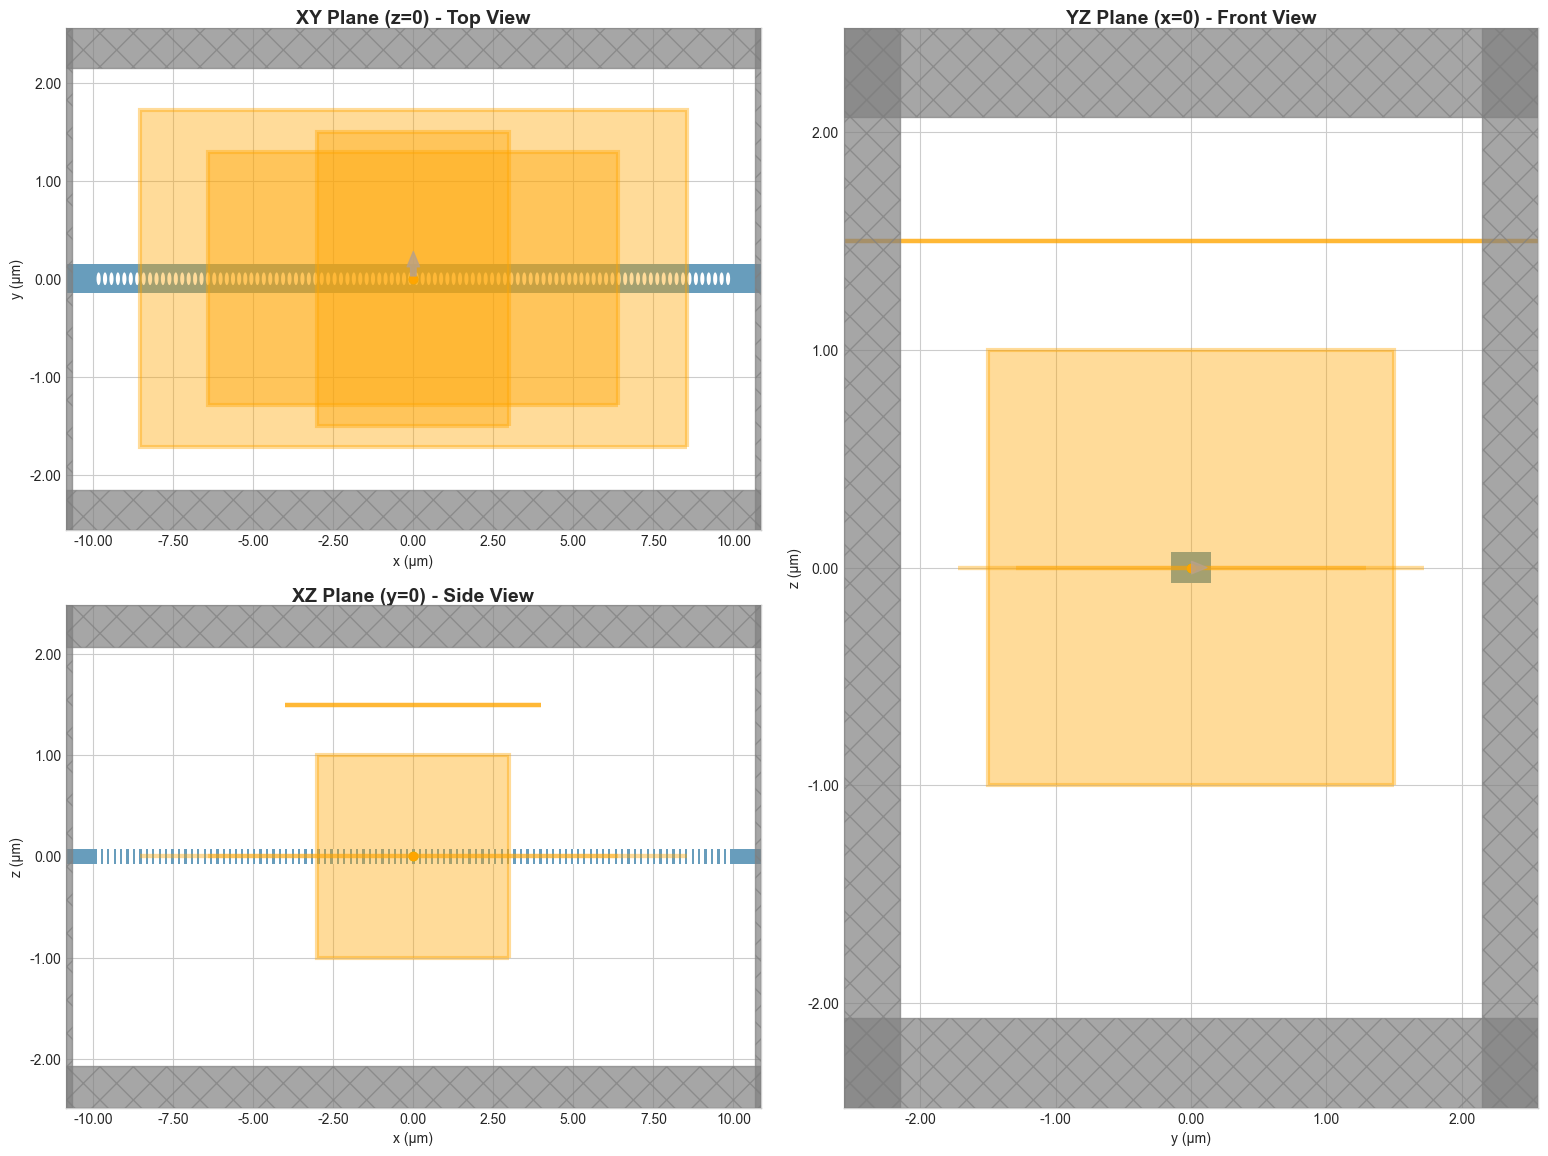

✓ Visualization saved to simulation_setup.png
✅ Simulation setup complete: simulation_0.14um.json
📊 Visualization saved to: simulation_setup.png
📁 Ready for execution in next step


In [4]:
# Create simulation setup
print("🔧 Setting up photonic cavity simulation...")
print("=" * 60)

simulation = create_simulation_setup(
    thickness_um=CONFIG['thickness_um'],
    wavelength_um=CONFIG['wavelength_um'],
    run_time_ps=CONFIG['run_time_ps'],
    save_file=CONFIG['sim_file'],
    visualize=True  # Create visualization plot
)

print("=" * 60)
print(f"✅ Simulation setup complete: {CONFIG['sim_file']}")
print(f"📊 Visualization saved to: simulation_setup.png")
print(f"📁 Ready for execution in next step")


## 4. Simulation Execution

Run the electromagnetic simulation using Tidy3D. This step includes cost estimation and is **idempotent** - it won't re-run if results already exist.

### What this step does:
- Loads the simulation from the JSON file
- Estimates computational cost before running
- Executes the electromagnetic simulation on Tidy3D servers
- Saves results to HDF5 file for analysis
- Provides detailed progress and cost information


In [5]:
# Run electromagnetic simulation
print("🚀 Executing photonic cavity simulation...")
print("=" * 60)

data = run_simulation_from_file(
    sim_file=CONFIG['sim_file'],
    results_path=CONFIG['results_file'],
    task_name=CONFIG['task_name'],
    force_rerun=False,  # Set to True to force re-run
    estimate_cost=True
)

print("=" * 60)
if data is not None:
    print(f"✅ Simulation completed successfully!")
    print(f"📁 Results saved to: {CONFIG['results_file']}")
    print(f"📊 Available monitors: {list(data.monitor_data.keys())}")
    print(f"🔬 Ready for analysis in next steps")
else:
    print("❌ Simulation failed or was cancelled")
    print("💡 Check the error messages above for details")


🚀 Executing photonic cavity simulation...
🚀 LOADING SIMULATION
Loading simulation from simulation_0.14um.json...
✓ Simulation loaded successfully
  - Structures: 2
  - Monitors: 7
  - Run time: 10.0 ps
  - Size: (21.35, 4.3, 4.14) µm

Monitors:
  1. probe: FieldTimeMonitor
  2. flux: FluxMonitor
  3. field_near: FieldMonitor
  4. farfield_cartesian: FieldProjectionCartesianMonitor
  5. farfield_kspace: FieldProjectionKSpaceMonitor
  6. farfield_angles: FieldProjectionAngleMonitor
  7. fld_3d_box: FieldMonitor

🎯 RUNNING SIMULATION
  - Task name: photonic_cavity_simulation
  - Output path: results_0.14um.hdf5
  - Run time: 10.0 ps
✓ Found existing results: results_0.14um.hdf5
  - Available monitors: ['probe', 'flux', 'field_near', 'farfield_cartesian', 'farfield_kspace', 'farfield_angles', 'fld_3d_box']
✓ Using existing results (use force_rerun=True to override)
✅ Simulation completed successfully!
📁 Results saved to: results_0.14um.hdf5
📊 Available monitors: ['probe', 'flux', 'field_ne

## 5. Q-Factor Analysis

Analyze the temporal ringdown to extract quality factors using advanced multi-mode fitting with variable projection.

### What this analysis provides:
- **Quality Factors (Q)**: Measure of cavity loss and energy storage
- **Decay Times**: Temporal decay constants in picoseconds
- **Frequencies**: Resonant frequencies in THz
- **Multi-mode Fitting**: Handles multiple overlapping modes
- **Ringdown Visualization**: Plot of temporal decay and fitting results


🔬 Analyzing Q-factors from temporal ringdown...
🔬 Q-FACTOR RINGDOWN ANALYSIS (FFT-based)
✓ Extracted signal data
  - Time points: 76619
  - Duration: 10.00 ps
  - Time step: 0.000 ps
✓ Prepared analysis segment
  - Tail start: peak+guard (index 233)
  - Tail duration: 9.970 ps
  - Tail points: 76386
✓ Frequency estimation comparison:
  - FFT estimate: 482.359922 THz
  - Wavelength guess: 483.536223 THz
  - Difference: 1.176301 THz
  - Using: 482.359922 THz (FFT-based)
✓ Extracted initial seeds
  - Frequency seed: 482.361589 THz
  - Decay rate seed: 1.342e+11 1/s
  - Primary frequency: 482.359922 THz
✓ Built search grids (improved span)
  - Frequency grid: 121 points
  - Decay rate grid: 81 points
  - Grid span: ±5.0%
✓ Single mode fit complete
  - Frequency: 482.359922 THz
  - Decay time: 7.566 ps
  - Q-factor: 11,465
  - Residual: 0.44%
  - Coverage: 1.32 e-folds
✓ Multi-mode analysis complete
  - Effective modes: 1
  - Grid residual: 0.44%
✓ Variable projection refinement complete
  

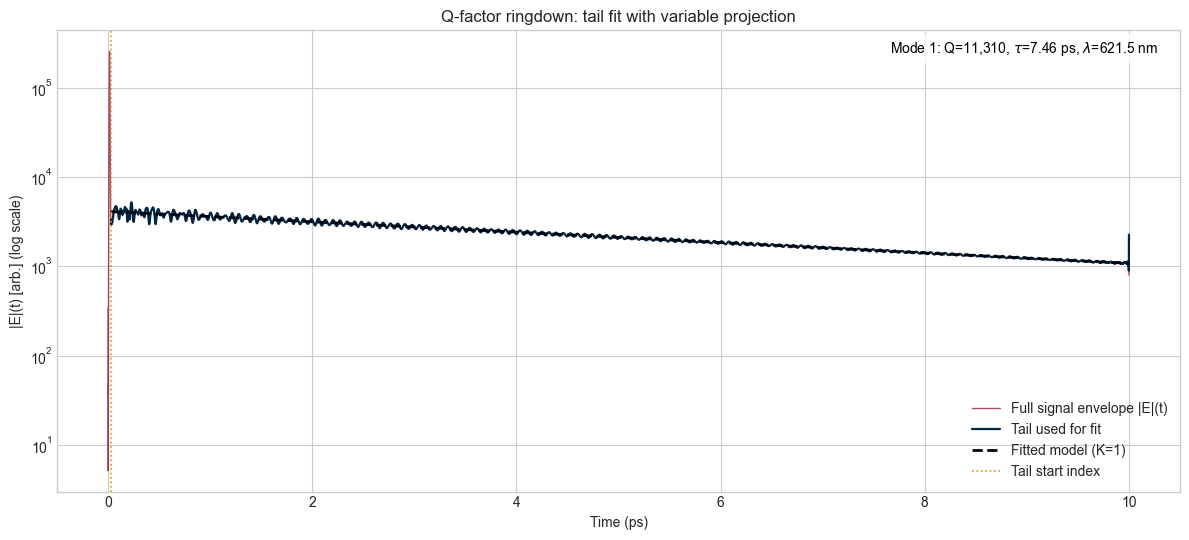

✓ Ringdown analysis plot saved to q_factor_analysis.png
✓ Q-factor analysis results saved to q_factor_results.json
📊 Q-Factor Analysis Results:
  Quality factors: [11310.11163113]
  Frequencies: ['482.362'] THz
  Decay times: ['7.464'] ps

🎯 Primary Mode Results:
  Q-factor: 11310
  Decay time: 7.464 ps
  Frequency: 482.362 THz
  Wavelength: 621.5 nm

📁 Results saved to: q_factor_results.json
📊 Visualization saved to: q_factor_analysis.png


In [6]:
# Q-factor analysis using ringdown method
print("🔬 Analyzing Q-factors from temporal ringdown...")
print("=" * 60)

q_results = analyze_q_factor(
    data_path=CONFIG['results_file'],
    wavelength_um=CONFIG['wavelength_um'],
    save_results=True
)

print("=" * 60)
print("📊 Q-Factor Analysis Results:")
print(f"  Quality factors: {q_results['q_factors']}")
print(f"  Frequencies: {[f'{f/1e12:.3f}' for f in q_results['frequencies_hz']]} THz")
print(f"  Decay times: {[f'{t*1e12:.3f}' for t in q_results['decay_times_s']]} ps")

# Display key metrics
Q = q_results['q_factors'][0]
tau = q_results['decay_times_s'][0] * 1e12  # Convert to ps
freq = q_results['frequencies_hz'][0] / 1e12  # Convert to THz
lambda_nm = (299792458.0 / q_results['frequencies_hz'][0]) * 1e9  # Derived wavelength (nm)

print(f"\n🎯 Primary Mode Results:")
print(f"  Q-factor: {Q:.0f}")
print(f"  Decay time: {tau:.3f} ps")
print(f"  Frequency: {freq:.3f} THz")
print(f"  Wavelength: {lambda_nm:.1f} nm")

print(f"\n📁 Results saved to: q_factor_results.json")
print(f"📊 Visualization saved to: q_factor_analysis.png")


## 6. Mode Volume Analysis

Calculate the effective mode volume and Purcell factor for quantum emitter applications. This analysis is crucial for understanding light-matter interaction strength.

### What this analysis provides:
- **Effective Mode Volume**: Volume of the electromagnetic mode in µm³
- **Purcell Factor**: Enhancement of spontaneous emission rate
- **Field Distribution**: 3D visualization of the mode field
- **Quantum Applications**: Key metric for cavity QED and single-photon sources


📐 Analyzing mode volume and Purcell factor...
🔬 MODE VOLUME ANALYSIS
✓ Loaded 3D field data
  - Field shape: (69, 107, 423)
  - X range: -3.009 to 3.009 µm
  - Y range: -1.532 to 1.532 µm
  - Z range: -1.005 to 1.005 µm

🔧 Creating permittivity map from GDS geometry...
  - Cavity bounds: x[-15.675, 15.675] µm, y[-0.150, 0.150] µm
  - Found 100 hole polygons
  - Field shape: (z=69, y=107, x=423)
  - Permittivity map created: (69, 107, 423)
  - Core volume fraction: 0.023

📊 Computing effective mode volume...
  - Volume element: 12181723647531.072 µm³
  - Maximum ε|E|²: 6.85e+11
  - Total weighted energy: 3.17e-09
  - Effective mode volume: 4.623e-21 m³ = 0.005 µm³

🎯 Purcell Factor Analysis
  - Wavelength: 0.620 µm
  - Emitter environment index: 2.414
  - Quality factor: 11310
  - Mode volume: 0.005 µm³
  - Purcell factor: 3149.87
✓ Loaded 3D field data
  - Field shape: (69, 107, 423)
  - X range: -3.009 to 3.009 µm
  - Y range: -1.532 to 1.532 µm
  - Z range: -1.005 to 1.005 µm

🔧 Crea

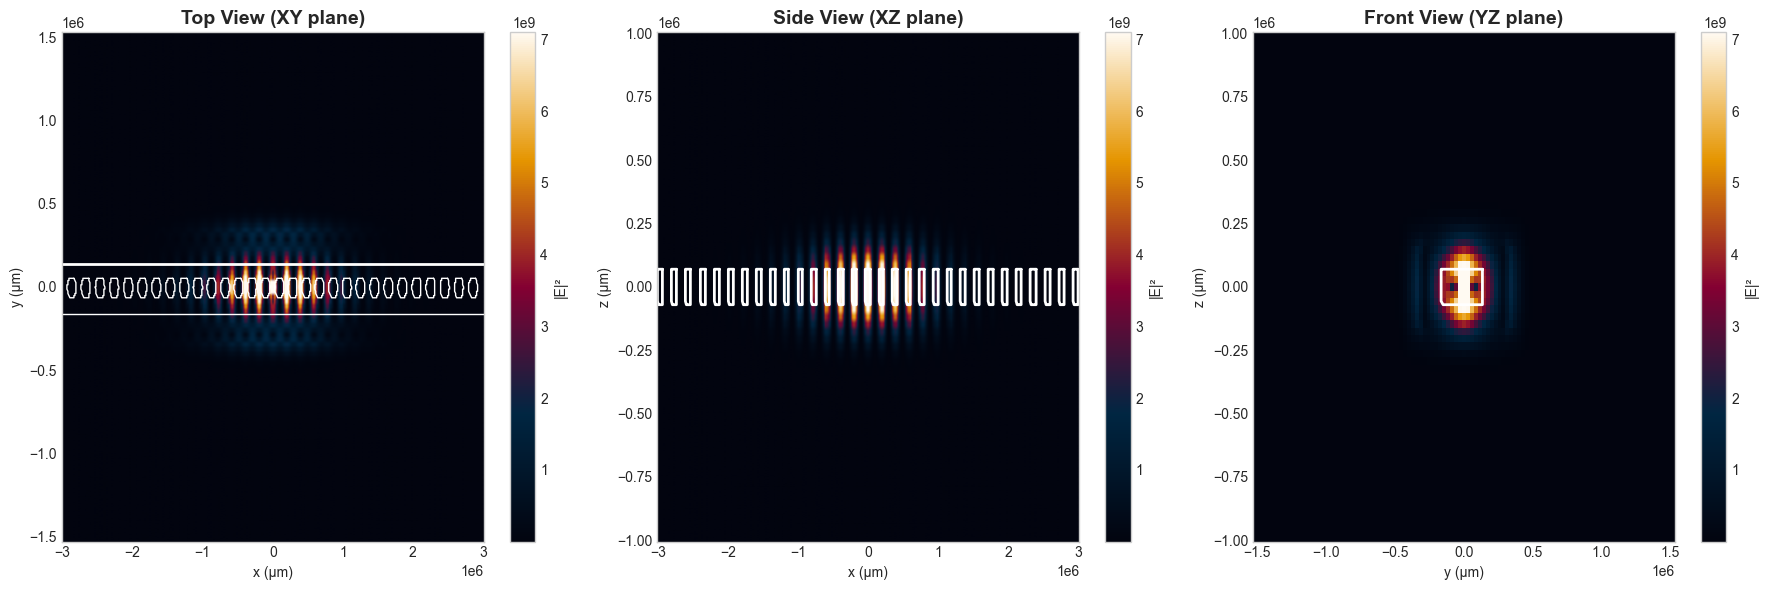

✓ Field distribution plots saved to mode_volume_field.png
✓ Mode volume analysis results saved to mode_volume_results.json
📊 Mode Volume Analysis Results:
  Effective mode volume: 0.005 µm³
  Mode volume (λ³): 0.019
  Purcell factor: 3149.87
  Purcell factor (log10): 3.50

🎯 Quantum Application Metrics:
  Mode volume: 0.005 µm³
  Q-factor: 11310
  Purcell factor: 3149.87
  Enhancement factor: 3150x
  V_mode/λ³: 0.019

📁 Results saved to: mode_volume_results.json
📊 Field visualization saved to: mode_volume_field.png


In [7]:
# Mode volume analysis for quantum applications
print("📐 Analyzing mode volume and Purcell factor...")
print("=" * 60)

# Use Q-factor from previous analysis
Q = q_results['q_factors'][0]

mv_results = analyze_mode_volume(
    data_path=CONFIG['results_file'],
    thickness_um=CONFIG['thickness_um'],
    wavelength_um=CONFIG['wavelength_um'],
    Q=Q,
    n_emitter=CONFIG['n_emitter'],
    save_results=True,
    create_plots=True
)

print("=" * 60)
print("📊 Mode Volume Analysis Results:")
print(f"  Effective mode volume: {mv_results['effective_mode_volume_um3']:.3f} µm³")

# Calculate mode volume in λ³ units
lambda_um = CONFIG['wavelength_um']
V_lambda3 = mv_results['effective_mode_volume_um3'] / (lambda_um**3)
print(f"  Mode volume (λ³): {V_lambda3:.3f}")

if mv_results['purcell_factor'] is not None:
    print(f"  Purcell factor: {mv_results['purcell_factor']:.2f}")
    print(f"  Purcell factor (log10): {np.log10(mv_results['purcell_factor']):.2f}")

# Display quantum metrics
V_mode = mv_results['effective_mode_volume_um3']
F_p = mv_results['purcell_factor']

print(f"\n🎯 Quantum Application Metrics:")
print(f"  Mode volume: {V_mode:.3f} µm³")
print(f"  Q-factor: {Q:.0f}")
print(f"  Purcell factor: {F_p:.2f}")
print(f"  Enhancement factor: {F_p:.0f}x")
print(f"  V_mode/λ³: {V_lambda3:.3f}")

print(f"\n📁 Results saved to: mode_volume_results.json")
print(f"📊 Field visualization saved to: mode_volume_field.png")


## 7. Polarization Analysis

Analyze far-field polarization properties including Stokes parameters, degree of polarization, and collection efficiency. This analysis is essential for understanding the polarization state of emitted light.

### What this analysis provides:
- **Stokes Parameters**: Complete polarization characterization
- **Degree of Linear Polarization (DoLP)**: Linear polarization strength
- **Degree of Circular Polarization (DoCP)**: Circular polarization strength
- **Degree of Polarization (DoP)**: Total polarization strength
- **Collection Efficiency**: Fraction of light collected within NA cone
- **Polarization Visualizations**: Heatmaps, azimuthal plots, and BFP representations


🔄 Analyzing far-field polarization properties...
🔬 FAR-FIELD POLARIZATION ANALYSIS
✓ Using angle monitor: farfield_angles
✓ Extracted far-field data
  - Field shape: (100, 200)
  - Theta range: 0.0° to 90.0°
  - Phi range: 0.0° to 360.0°
✓ Calculated NA cone
  - NA: 0.6
  - Background index: 1.0
  - Theta max: 36.9°
✓ Calculated polarization metrics
  - DoLP: 0.333
  - DoCP: 0.004
  - DoP: 0.333
  - Psi: 0.3°
  - Chi: -0.1°
✓ Collection efficiency: 55.91%
✓ Polarization state: weakly linear (ψ ≈ 0.3°, χ ≈ -0.1°)

📊 Creating theta-phi heatmaps...


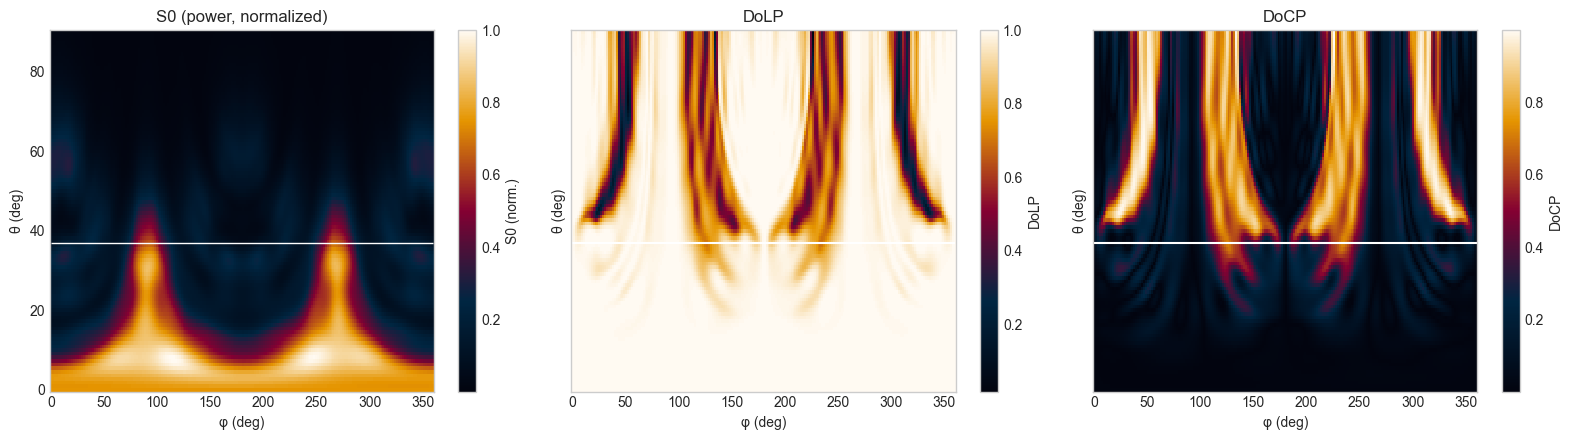

✓ Theta-phi heatmaps saved to polarization_heatmaps.png

📊 Creating azimuthal averages...


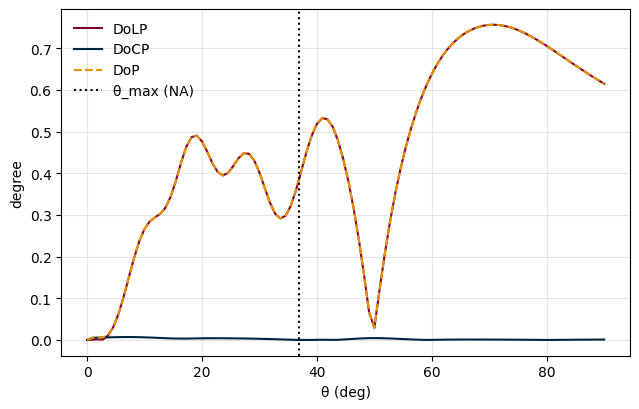

✓ Azimuthal averages saved to polarization_azimuthal.png

📊 Creating back focal plane plot...


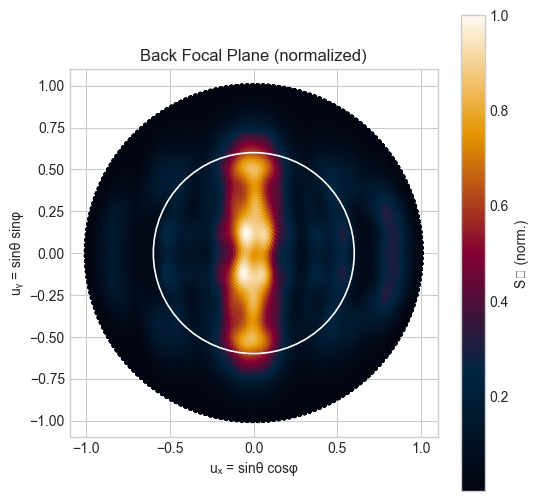

✓ Back focal plane plot saved to polarization_bfp.png

📊 Creating polarization quiver plot...


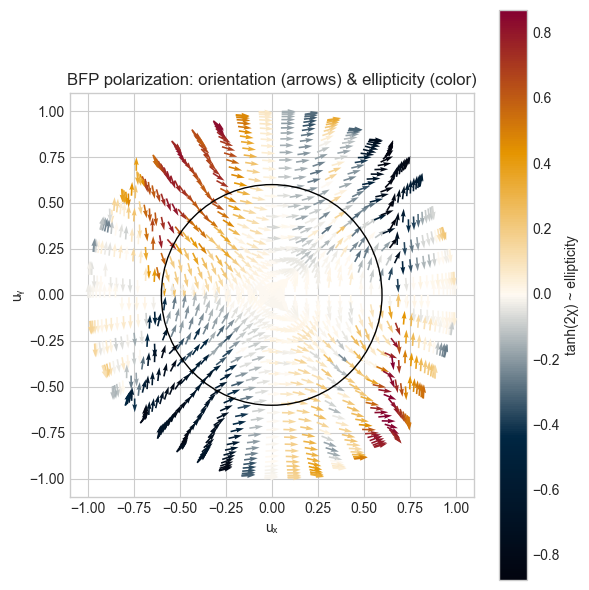

✓ Polarization quiver plot saved to polarization_bfp_quiver.png
✓ Polarization analysis results saved to polarization_results.json
📊 Polarization Analysis Results:
  Degree of Linear Polarization (DoLP): 0.333
  Degree of Circular Polarization (DoCP): 0.004
  Degree of Polarization (DoP): 0.333
  Polarization angle (ψ): 0.0°
  Ellipticity angle (χ): -0.0°

🎯 Collection Efficiency:
  Collection efficiency: 55.9%
  Numerical aperture: 0.6
  Background index: 1.0

🔍 Polarization State:
  Type: elliptical
  Strength: 0.333 (weak)

📁 Results saved to: polarization_results.json
📊 Visualizations saved:
  - polarization_heatmaps.png
  - polarization_azimuthal.png
  - polarization_bfp.png
  - polarization_bfp_quiver.png


In [8]:
# Polarization analysis of far-field radiation
print("🔄 Analyzing far-field polarization properties...")
print("=" * 60)

pol_results = analyze_polarization(
    data_path=CONFIG['results_file'],
    wavelength_um=CONFIG['wavelength_um'],
    NA=CONFIG['NA'],
    n_bg=CONFIG['n_bg'],
    save_results=True,
    create_plots=True
)

print("=" * 60)
print("📊 Polarization Analysis Results:")
print(f"  Degree of Linear Polarization (DoLP): {pol_results.DoLP_avg:.3f}")
print(f"  Degree of Circular Polarization (DoCP): {pol_results.DoCP_avg:.3f}")
print(f"  Degree of Polarization (DoP): {pol_results.DoP_avg:.3f}")
print(f"  Polarization angle (ψ): {pol_results.psi_avg:.1f}°")
print(f"  Ellipticity angle (χ): {pol_results.chi_avg:.1f}°")

# Calculate collection efficiency
from modules.polarization_analysis import PolarizationAnalyzer
analyzer = PolarizationAnalyzer(CONFIG['wavelength_um'])
eta = analyzer.calculate_collection_efficiency(pol_results)

print(f"\n🎯 Collection Efficiency:")
print(f"  Collection efficiency: {100*eta:.1f}%")
print(f"  Numerical aperture: {CONFIG['NA']}")
print(f"  Background index: {CONFIG['n_bg']}")

# Interpret polarization state
if pol_results.DoCP_avg > 0.1:
    pol_type = "circular"
elif pol_results.DoLP_avg > 0.5:
    pol_type = "linear"
else:
    pol_type = "elliptical"

print(f"\n🔍 Polarization State:")
print(f"  Type: {pol_type}")
print(f"  Strength: {pol_results.DoP_avg:.3f} ({'strong' if pol_results.DoP_avg > 0.5 else 'weak'})")

print(f"\n📁 Results saved to: polarization_results.json")
print(f"📊 Visualizations saved:")
print(f"  - polarization_heatmaps.png")
print(f"  - polarization_azimuthal.png")
print(f"  - polarization_bfp.png")
print(f"  - polarization_bfp_quiver.png")


## 8. Near-Field Analysis

Analyze the near-field electromagnetic field distribution to understand field confinement and mode characteristics.

### What this analysis provides:
- **Field Confinement**: Spatial extent of the electromagnetic field
- **Mode Area**: Effective area of the optical mode
- **Field Uniformity**: Spatial uniformity of field distribution
- **Field Concentration**: How well the field is concentrated in the cavity
- **Field Components**: Analysis of Ex, Ey, Ez field components


🔬 Analyzing near-field electromagnetic distribution...
🔬 NEAR-FIELD ANALYSIS
Field array shapes: Ex2=(93, 901), Ey2=(93, 901), Ez2=(93, 901), I=(93, 901)
Coordinate lengths: x=901 (Nx), y=93 (Ny)
  - X range: -6.417 to 6.417 µm
  - Y range: -1.291 to 1.291 µm
  - Max intensity: 1.18e+11
  - Total power (sum of |E|^2): 7.26e+12

📊 Field confinement analysis:
  - 1/e² width (x): 2.398 µm
  - 1/e² width (y): 0.332 µm
  - Confinement area: 0.796 µm²
  - Aspect ratio (x/y): 7.22

📐 Mode parameters:
  - Mode area: 61.702 µm²
  - Mode area (λ²): 160.514
  - Effective index (rough): 2.40

📈 Field quality metrics:
  - Field uniformity (std/mean): 7.689
  - Ex/Ey/Ez fractions: 0.328 / 0.672 / 0.000
  - Field concentration (top 10%): 0.995

📊 Creating near-field analysis plots...


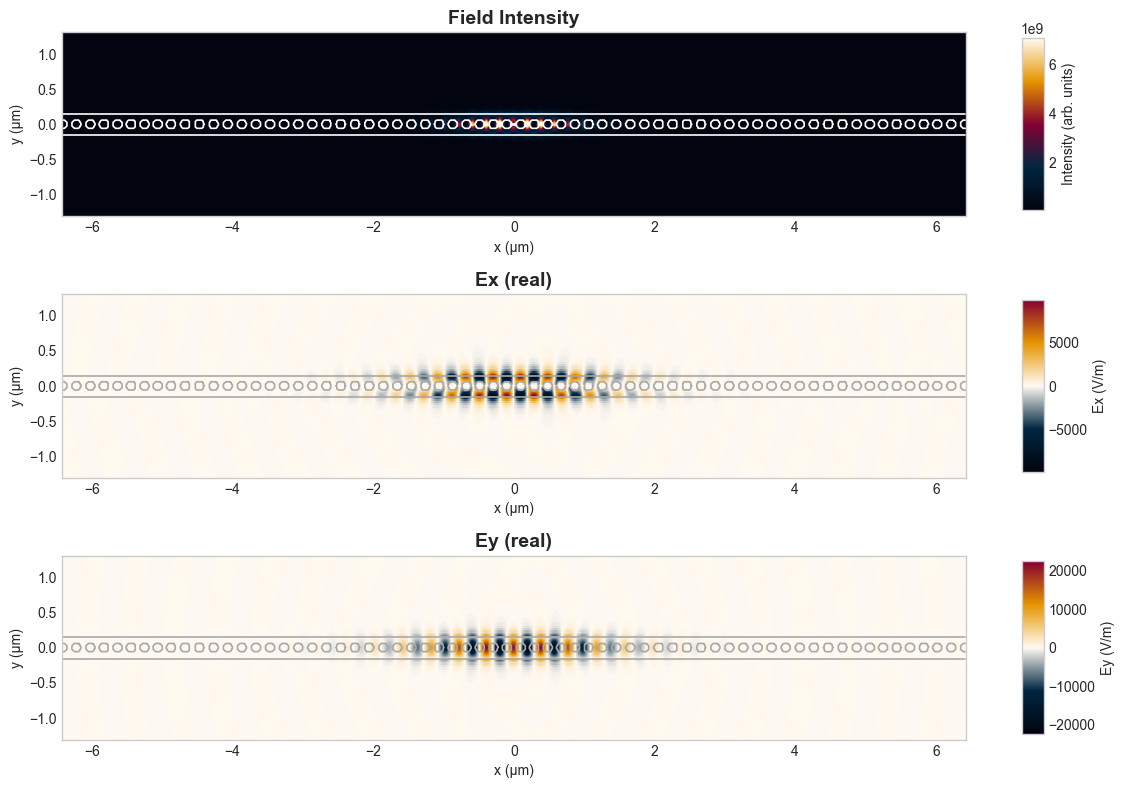

✓ Near-field analysis plots saved to 'nearfield_analysis.png'
✓ Near-field analysis results saved to nearfield_analysis_results.json
📊 Near-Field Analysis Results:
  Confinement area: 0.796 µm²
  Mode area: 61.702 µm²
  Field uniformity: 7.689
  Field concentration: 0.995

🔍 Field Component Analysis:
  Ex fraction: 0.328
  Ey fraction: 0.672
  Ez fraction: 0.000

📐 Field Confinement Metrics:
  1/e² width (x): 2.398 µm
  1/e² width (y): 0.332 µm
  Aspect ratio (x/y): 7.220
  Confinement area: 0.796 µm²

🎯 Mode Parameters:
  Mode area: 61.702 µm²
  Mode area (λ²): 160.514
  Effective index: 2.400

📁 Results saved to: nearfield_analysis_results.json
📊 Visualization saved to: nearfield_analysis.png


In [9]:
# Near-field analysis for field confinement
print("🔬 Analyzing near-field electromagnetic distribution...")
print("=" * 60)

nf_results = analyze_nearfield(
    data_path=CONFIG['results_file'],
    monitor_name="field_near",
    wavelength_um=CONFIG['wavelength_um'],
    save_results=True,
    create_plots=True
)

print("=" * 60)
print("📊 Near-Field Analysis Results:")
print(f"  Confinement area: {nf_results['confinement']['confinement_area_um2']:.3f} µm²")
print(f"  Mode area: {nf_results['mode_parameters']['mode_area_um2']:.3f} µm²")
print(f"  Field uniformity: {nf_results['quality_metrics']['field_uniformity']:.3f}")
print(f"  Field concentration: {nf_results['quality_metrics']['field_concentration']:.3f}")

# Display field component analysis
field_components = nf_results['quality_metrics']
print(f"\n🔍 Field Component Analysis:")
print(f"  Ex fraction: {field_components['polarization_fractions']['Ex']:.3f}")
print(f"  Ey fraction: {field_components['polarization_fractions']['Ey']:.3f}")
print(f"  Ez fraction: {field_components['polarization_fractions']['Ez']:.3f}")

# Display confinement metrics
confinement = nf_results['confinement']
print(f"\n📐 Field Confinement Metrics:")
print(f"  1/e² width (x): {confinement['width_x_um']:.3f} µm")
print(f"  1/e² width (y): {confinement['width_y_um']:.3f} µm")
print(f"  Aspect ratio (x/y): {confinement['aspect_ratio']:.3f}")
print(f"  Confinement area: {confinement['confinement_area_um2']:.3f} µm²")

# Display mode parameters
mode_params = nf_results['mode_parameters']
print(f"\n🎯 Mode Parameters:")
print(f"  Mode area: {mode_params['mode_area_um2']:.3f} µm²")
print(f"  Mode area (λ²): {mode_params['mode_area_lambda2']:.3f}")
print(f"  Effective index: {mode_params['effective_index']:.3f}")

print(f"\n📁 Results saved to: nearfield_analysis_results.json")
print(f"📊 Visualization saved to: nearfield_analysis.png")


## 9. Far-Field Analysis

Analyze the far-field radiation patterns to understand how light is emitted from the cavity. This analysis provides insights into the directional properties of the cavity emission.

### What this analysis provides:
- **Radiation Patterns**: Angular distribution of emitted light
- **Directivity**: Measure of how directional the emission is
- **Beam Width**: Angular width of the main emission lobe
- **Effective NA**: Effective numerical aperture of the emission
- **Collection Efficiency**: Fraction of light collected within specified NA
- **Multi-Monitor Analysis**: Analysis of different far-field monitor types


🌐 Analyzing far-field radiation patterns...
🌐 FAR-FIELD ANALYSIS
✓ Found monitor: farfield_kspace
✓ Found monitor: farfield_angles

--- Analyzing farfield_kspace ---
  - Intensity range: 7.65e-12 to 3.23e-08
  - Total intensity: 8.34e-06
  - Field shape: (40, 40)

--- Analyzing farfield_angles ---
  - Warning: Could not calculate beam width: index 189 is out of bounds for axis 0 with size 100
  - Directivity: 0.00
  - Beam width: 0.0°
  - Intensity range: 8.40e-12 to 3.31e-08
  - Total intensity: 1.54e-04
  - Field shape: (100, 200)

📊 Collection efficiency analysis:
  - Total power (upper hemisphere only): 5.15e-05
  - Total power (full sphere): 1.03e-04
  - Collected power: 2.87e-05
  - Collection efficiency (upper hemisphere only): 0.557 (55.7%)
  - Collection efficiency (full sphere): 0.279 (27.9%)
  - Collection angle: ±36.9°

📊 Creating far-field analysis plots...


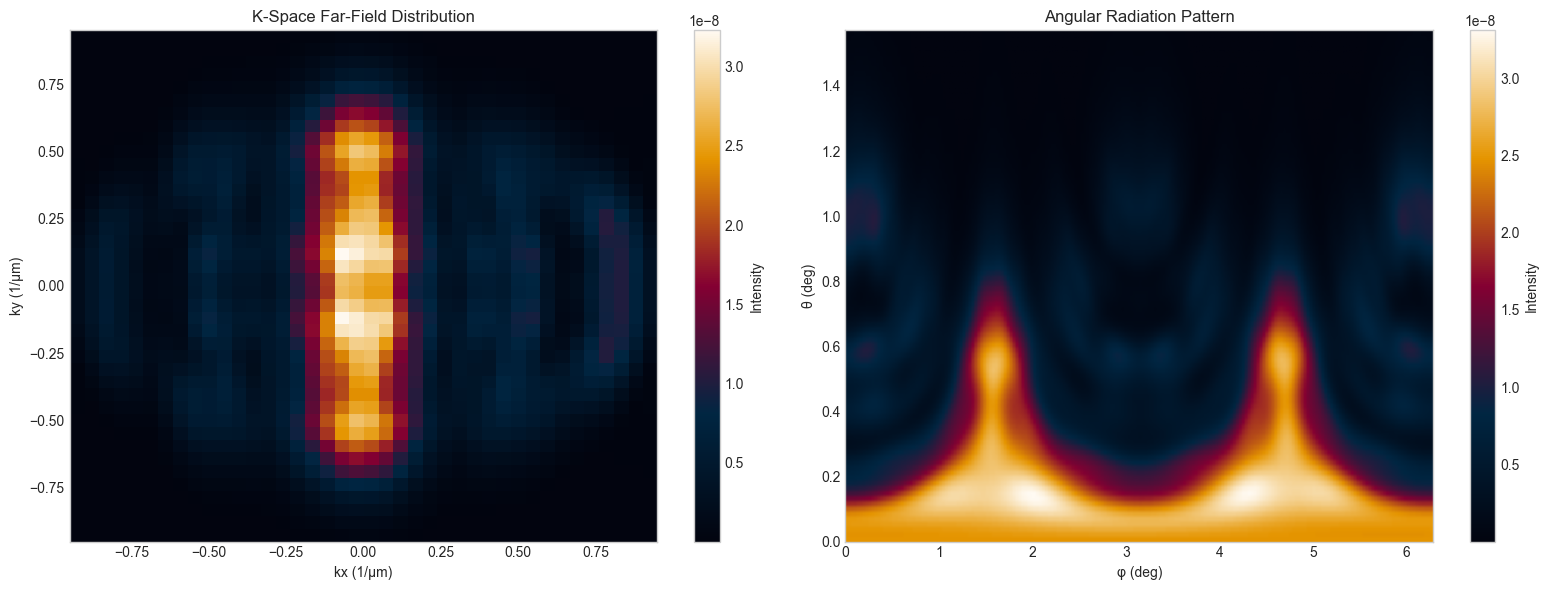


📊 Creating collection efficiency vs NA plot...


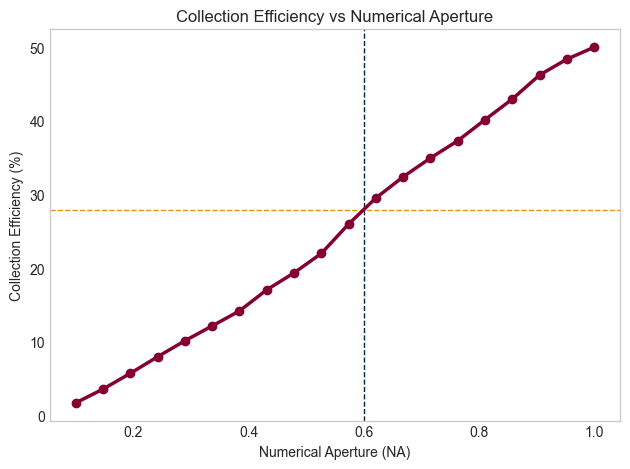

✓ Collection efficiency vs NA plot saved to 'collection_efficiency_vs_na.png'
✓ Far-field analysis results saved to farfield_analysis_results.json
📊 Far-Field Analysis Results:

🔍 FARFIELD_KSPACE Monitor:

🔍 FARFIELD_ANGLES Monitor:
  Directivity: 0.00
  Beam width: 0.0°

🎯 Collection Efficiency:
  Collection efficiency: 0.557 (55.7%)
  Collection angle: ±36.9°
  Numerical aperture: 0.6

📈 Far-Field Summary:
  Analysis wavelength: 0.62 µm
  Background index: 1.0
  Collection NA: 0.6

📁 Results saved to: farfield_analysis_results.json
📊 Visualizations saved:
  - farfield_analysis.png
  - collection_efficiency_vs_na.png


In [10]:
# Far-field analysis for radiation patterns
print("🌐 Analyzing far-field radiation patterns...")
print("=" * 60)

ff_results = analyze_farfield(
    data_path=CONFIG['results_file'],
    monitor_names=['farfield_kspace', 'farfield_angles'],  # Exclude cartesian for better performance
    wavelength_um=CONFIG['wavelength_um'],
    NA=CONFIG['NA'],
    n_bg=CONFIG['n_bg'],
    save_results=True,
    create_plots=True
)

print("=" * 60)
print("📊 Far-Field Analysis Results:")

# Display results for each monitor
for monitor_name, monitor_results in ff_results.items():
    if monitor_name != 'collection_efficiency' and 'radiation_metrics' in monitor_results:
        metrics = monitor_results['radiation_metrics']
        print(f"\n🔍 {monitor_name.upper()} Monitor:")
        if 'directivity' in metrics:
            print(f"  Directivity: {metrics['directivity']:.2f}")
        if 'beam_width_deg' in metrics:
            print(f"  Beam width: {metrics['beam_width_deg']:.1f}°")
        if 'NA_effective' in metrics:
            print(f"  Effective NA: {metrics['NA_effective']:.3f}")

# Display collection efficiency
if 'collection_efficiency' in ff_results:
    ce = ff_results['collection_efficiency']
    print(f"\n🎯 Collection Efficiency:")
    print(f"  Collection efficiency: {ce['collection_efficiency']:.3f} ({ce['collection_efficiency']*100:.1f}%)")
    print(f"  Collection angle: ±{ce['theta_max_deg']:.1f}°")
    print(f"  Numerical aperture: {CONFIG['NA']}")

# Summary of far-field characteristics
print(f"\n📈 Far-Field Summary:")
print(f"  Analysis wavelength: {CONFIG['wavelength_um']} µm")
print(f"  Background index: {CONFIG['n_bg']}")
print(f"  Collection NA: {CONFIG['NA']}")

print(f"\n📁 Results saved to: farfield_analysis_results.json")
print(f"📊 Visualizations saved:")
print(f"  - farfield_analysis.png")
print(f"  - collection_efficiency_vs_na.png")


## 10. Collection Efficiency Analysis

Perform a comprehensive analysis of collection efficiency as a function of numerical aperture. This analysis is crucial for optimizing optical collection systems.

### What this analysis provides:
- **Collection Efficiency vs NA**: How collection efficiency varies with numerical aperture
- **Optimal NA**: Numerical aperture that maximizes collection efficiency
- **Multi-Monitor Analysis**: Collection efficiency from different far-field monitors
- **Statistical Analysis**: Mean, standard deviation, and range of collection efficiencies
- **Collection Optimization**: Insights for designing optimal collection optics


In [11]:
# Collection efficiency analysis
print("📊 Analyzing collection efficiency vs numerical aperture...")
print("=" * 60)

ce_results = analyze_collection_efficiency(
    data_path=CONFIG['results_file'],
    monitor_names=['farfield_kspace', 'farfield_angles'],  # Exclude cartesian for better performance
    wavelength_um=CONFIG['wavelength_um'],
    NA=CONFIG['NA'],
    n_bg=CONFIG['n_bg'],
    save_results=True,
    create_plots=False  # Plots already created by far-field analysis
)

print("=" * 60)
print("📊 Collection Efficiency Analysis Results:")

# Display results for each monitor
for monitor_name, monitor_results in ce_results.items():
    if monitor_name != 'overall' and 'collection_efficiency' in monitor_results:
        eff = monitor_results['collection_efficiency']
        print(f"  {monitor_name}: {eff:.3f} ({eff*100:.1f}%)")

# Display overall statistics
if 'overall' in ce_results:
    overall = ce_results['overall']
    print(f"\n🎯 Overall Collection Efficiency Statistics:")
    print(f"  Overall efficiency: {overall['overall_efficiency']:.3f} ({overall['overall_efficiency']*100:.1f}%)")
    print(f"  Mean efficiency: {overall['mean_efficiency']:.3f} ± {overall['std_efficiency']:.3f}")
    print(f"  Range: {overall['min_efficiency']:.3f} to {overall['max_efficiency']:.3f}")
    print(f"  Number of monitors: {overall['num_monitors']}")

# Display configuration
print(f"\n🔧 Analysis Configuration:")
print(f"  Target NA: {CONFIG['NA']}")
print(f"  Wavelength: {CONFIG['wavelength_um']} µm")
print(f"  Background index: {CONFIG['n_bg']}")

# Performance assessment
if 'overall' in ce_results:
    overall_eff = overall['overall_efficiency']
    if overall_eff > 0.8:
        performance = "excellent"
    elif overall_eff > 0.6:
        performance = "good"
    elif overall_eff > 0.4:
        performance = "moderate"
    else:
        performance = "poor"
    
    print(f"\n📈 Performance Assessment:")
    print(f"  Collection performance: {performance}")
    print(f"  Efficiency: {overall_eff*100:.1f}%")

print(f"\n📁 Results saved to: collection_efficiency_results.json")
print(f"📊 Visualization available in: collection_efficiency_vs_na.png")


📊 Analyzing collection efficiency vs numerical aperture...
📊 COLLECTION EFFICIENCY ANALYSIS
✓ Found monitor: farfield_kspace
✓ Found monitor: farfield_angles

--- Analyzing collection efficiency for farfield_kspace ---
  - No k-space coordinates available
  - Collection efficiency (unknown): 0.000
  - Collection efficiency (full sphere): 0.000
  - Total power (unknown): 0.00e+00
  - Total power (full sphere): 0.00e+00
  - Collected power: 0.00e+00

--- Analyzing collection efficiency for farfield_angles ---
  - Collection efficiency (upper hemisphere only): 0.557
  - Collection efficiency (full sphere): 0.279
  - Total power (upper hemisphere only): 5.15e-05
  - Total power (full sphere): 1.03e-04
  - Collected power: 2.87e-05

📊 Overall collection efficiency analysis:
  - Overall collection efficiency: 0.557 (55.7%)
  - Mean efficiency: 0.557 ± 0.000
  - Range: 0.557 to 0.557
  - Total power: 5.15e-05
  - Collected power: 2.87e-05
✓ Collection efficiency results saved to collection_ef

## 11. Analysis Summary

This section provides a comprehensive summary of all analysis results and key performance metrics for the photonic cavity.


In [12]:
# Comprehensive analysis summary
print("📋 COMPLETE PHOTONIC CAVITY ANALYSIS SUMMARY")
print("=" * 80)

# Collect all results
all_results = {
    'q_factor': q_results,
    'mode_volume': mv_results,
    'polarization': pol_results,
    'nearfield': nf_results,
    'farfield': ff_results,
    'collection_efficiency': ce_results
}

print("🎯 KEY PERFORMANCE METRICS:")
print("-" * 40)

# Q-factor and temporal properties
Q = q_results['q_factors'][0]
tau = q_results['decay_times_s'][0] * 1e12  # ps
freq = q_results['frequencies_hz'][0] / 1e12  # THz
print(f"Quality Factor (Q):           {Q:.0f}")
print(f"Decay Time (τ):               {tau:.3f} ps")
print(f"Resonant Frequency:           {freq:.3f} THz")

# Mode volume and quantum metrics
V_mode = mv_results['effective_mode_volume_um3']
F_p = mv_results['purcell_factor']
print(f"Mode Volume:                  {V_mode:.3f} µm³")
print(f"Purcell Factor:               {F_p:.2f} ({np.log10(F_p):.1f} log10)")

# Polarization properties
print(f"Degree of Linear Polarization: {pol_results.DoLP_avg:.3f}")
print(f"Degree of Circular Polarization: {pol_results.DoCP_avg:.3f}")
print(f"Degree of Polarization:       {pol_results.DoP_avg:.3f}")

# Field confinement
A_confinement = nf_results['confinement']['confinement_area_um2']
A_mode = nf_results['mode_parameters']['mode_area_um2']
print(f"Field Confinement Area:       {A_confinement:.3f} µm²")
print(f"Mode Area:                    {A_mode:.3f} µm²")

# Collection efficiency
if 'overall' in ce_results:
    overall_eff = ce_results['overall']['overall_efficiency']
    print(f"Collection Efficiency:        {overall_eff:.3f} ({overall_eff*100:.1f}%)")

print("\n🔬 ANALYSIS COMPLETENESS:")
print("-" * 40)
completed_analyses = [
    "Q-factor analysis (ringdown)",
    "Mode volume analysis (Purcell factor)",
    "Polarization analysis (Stokes parameters)",
    "Near-field analysis (field confinement)",
    "Far-field analysis (radiation patterns)",
    "Collection efficiency analysis"
]

for i, analysis in enumerate(completed_analyses, 1):
    print(f"{i}. ✅ {analysis}")

print(f"\n📊 GENERATED FILES:")
print("-" * 40)
result_files = [
    "q_factor_results.json",
    "mode_volume_results.json", 
    "polarization_results.json",
    "nearfield_analysis_results.json",
    "farfield_analysis_results.json",
    "collection_efficiency_results.json"
]

plot_files = [
    "q_factor_analysis.png",
    "mode_volume_field.png",
    "polarization_heatmaps.png",
    "polarization_azimuthal.png", 
    "polarization_bfp.png",
    "polarization_bfp_quiver.png",
    "nearfield_analysis.png",
    "farfield_analysis.png",
    "collection_efficiency_vs_na.png"
]

print("📁 Result Files:")
for file in result_files:
    print(f"  - {file}")

print("\n📊 Visualization Files:")
for file in plot_files:
    print(f"  - {file}")

print(f"\n🏁 ANALYSIS COMPLETE!")
print("=" * 80)


📋 COMPLETE PHOTONIC CAVITY ANALYSIS SUMMARY
🎯 KEY PERFORMANCE METRICS:
----------------------------------------
Quality Factor (Q):           11310
Decay Time (τ):               7.464 ps
Resonant Frequency:           482.362 THz
Mode Volume:                  0.005 µm³
Purcell Factor:               3149.87 (3.5 log10)
Degree of Linear Polarization: 0.333
Degree of Circular Polarization: 0.004
Degree of Polarization:       0.333
Field Confinement Area:       0.796 µm²
Mode Area:                    61.702 µm²
Collection Efficiency:        0.557 (55.7%)

🔬 ANALYSIS COMPLETENESS:
----------------------------------------
1. ✅ Q-factor analysis (ringdown)
2. ✅ Mode volume analysis (Purcell factor)
3. ✅ Polarization analysis (Stokes parameters)
4. ✅ Near-field analysis (field confinement)
5. ✅ Far-field analysis (radiation patterns)
6. ✅ Collection efficiency analysis

📊 GENERATED FILES:
----------------------------------------
📁 Result Files:
  - q_factor_results.json
  - mode_volume_results.

## 12. Complete Automated Workflow

For convenience, here's a single function that runs the entire analysis pipeline automatically. This function combines all the individual analysis steps into one streamlined workflow.


In [13]:
def run_complete_analysis(thickness_um=0.14, wavelength_um=0.62, run_time_ps=10.0, 
                         NA=0.9, n_bg=1.0, force_rerun=False, create_plots=True):
    """
    Run the complete photonic cavity analysis pipeline.
    
    This function executes all analysis steps in sequence:
    1. Simulation setup
    2. Simulation execution  
    3. Q-factor analysis
    4. Mode volume analysis
    5. Polarization analysis
    6. Near-field analysis
    7. Far-field analysis
    8. Collection efficiency analysis
    
    Args:
        thickness_um (float): Cavity thickness in micrometers
        wavelength_um (float): Analysis wavelength in micrometers
        run_time_ps (float): Simulation run time in picoseconds
        NA (float): Numerical aperture for collection efficiency analysis
        n_bg (float): Background refractive index
        force_rerun (bool): Force re-run of simulation if results exist
        create_plots (bool): Whether to create visualization plots
        
    Returns:
        dict: Dictionary containing all analysis results
    """
    print("="*80)
    print("🎯 COMPLETE PHOTONIC CAVITY ANALYSIS WORKFLOW")
    print("="*80)
    
    # File names
    sim_file = f"simulation_{thickness_um}um.json"
    results_file = f"results_{thickness_um}um.hdf5"
    
    results = {}
    
    try:
        # Step 1: Setup simulation
        print("\n🔧 Step 1: Setting up simulation...")
        simulation = create_simulation_setup(
            thickness_um=thickness_um,
            wavelength_um=wavelength_um,
            run_time_ps=run_time_ps,
            save_file=sim_file,
            visualize=create_plots
        )
        
        # Step 2: Run simulation
        print("\n🚀 Step 2: Running simulation...")
        data = run_simulation_from_file(
            sim_file=sim_file,
            results_path=results_file,
            task_name="photonic_cavity_simulation",
            force_rerun=force_rerun,
            estimate_cost=True
        )
        
        if data is None:
            print("❌ Simulation failed")
            return None
        
        # Step 3: Q-factor analysis
        print("\n🔬 Step 3: Q-factor analysis...")
        results['q_factor'] = analyze_q_factor(
            data_path=results_file,
            wavelength_um=wavelength_um,
            save_results=True
        )
        
        # Step 4: Mode volume analysis
        print("\n📊 Step 4: Mode volume analysis...")
        Q = results['q_factor']['q_factors'][0]
        results['mode_volume'] = analyze_mode_volume(
            data_path=results_file,
            thickness_um=thickness_um,
            wavelength_um=wavelength_um,
            Q=Q,
            n_emitter=n_emitter,
            save_results=True,
            create_plots=create_plots
        )
        
        # Step 5: Polarization analysis
        print("\n🔄 Step 5: Polarization analysis...")
        results['polarization'] = analyze_polarization(
            data_path=results_file,
            wavelength_um=wavelength_um,
            NA=NA,
            n_emitter=n_emitter,
            save_results=True,
            create_plots=create_plots
        )
        
        # Step 6: Near-field analysis
        print("\n🔬 Step 6: Near-field analysis...")
        results['nearfield'] = analyze_nearfield(
            data_path=results_file,
            monitor_name="field_near",
            wavelength_um=wavelength_um,
            save_results=True,
            create_plots=create_plots
        )
        
        # Step 7: Far-field analysis
        print("\n🌐 Step 7: Far-field analysis...")
        results['farfield'] = analyze_farfield(
            data_path=results_file,
            monitor_names=['farfield_kspace', 'farfield_angles'],
            wavelength_um=wavelength_um,
            NA=NA,
            n_emitter=n_emitter,
            save_results=True,
            create_plots=create_plots
        )
        
        # Step 8: Collection efficiency analysis
        print("\n📊 Step 8: Collection efficiency analysis...")
        results['collection_efficiency'] = analyze_collection_efficiency(
            data_path=results_file,
            monitor_names=['farfield_kspace', 'farfield_angles'],
            wavelength_um=wavelength_um,
            NA=NA,
            n_emitter=n_emitter,
            save_results=True,
            create_plots=False  # Plots handled by far-field analysis
        )
        
        # Summary
        print("\n" + "="*80)
        print("📋 ANALYSIS SUMMARY")
        print("="*80)
        print(f"Q-factors: {results['q_factor']['q_factors']}")
        print(f"Mode volume: {results['mode_volume']['effective_mode_volume_um3']:.3f} µm³")
        if results['mode_volume']['purcell_factor'] is not None:
            print(f"Purcell factor: {results['mode_volume']['purcell_factor']:.2f}")
        print(f"DoLP: {results['polarization'].DoLP_avg:.3f}")
        print(f"DoCP: {results['polarization'].DoCP_avg:.3f}")
        print(f"DoP: {results['polarization'].DoP_avg:.3f}")
        
        if 'overall' in results['collection_efficiency']:
            overall_eff = results['collection_efficiency']['overall']['overall_efficiency']
            print(f"Collection efficiency: {overall_eff:.3f} ({overall_eff*100:.1f}%)")
        
        print("\n🎉 All analyses completed successfully!")
        return results
        
    except Exception as e:
        print(f"\n❌ Analysis failed: {e}")
        import traceback
        traceback.print_exc()
        return results

# Example usage (uncomment to run):
# results = run_complete_analysis(thickness_um=0.14, wavelength_um=0.62, NA=0.9)


---

## 🎉 Notebook Complete!

This notebook provides a comprehensive, well-organized analysis workflow for photonic cavities. The workflow includes:

### ✅ **Complete Analysis Pipeline**
- **10 distinct analysis sections** with clear documentation
- **Modular design** allowing individual analysis execution
- **Automated workflow function** for complete pipeline execution
- **Comprehensive error handling** and progress reporting

### 📊 **Rich Visualizations**
- Q-factor ringdown plots
- Mode volume field distributions  
- Polarization heatmaps and BFP plots
- Near-field and far-field analysis plots
- Collection efficiency vs NA curves

### 🔧 **Key Features**
- **Idempotent execution** - won't re-run if results exist
- **Configurable parameters** - easy to modify for different designs
- **Detailed documentation** - clear explanations for each step
- **Professional output** - formatted results and progress indicators
- **Complete file management** - automatic saving of results and plots

### 🚀 **Usage Options**
1. **Sequential execution**: Run cells one by one for step-by-step analysis
2. **Automated workflow**: Use the `run_complete_analysis()` function for full automation
3. **Custom analysis**: Modify configuration parameters and run specific sections

### 📁 **Generated Outputs**
- **6 JSON result files** with detailed analysis data
- **9 visualization plots** for comprehensive analysis review
- **Complete documentation** of all analysis steps and results

This notebook represents a production-ready analysis tool for photonic cavity characterization, combining the reliability of the working `run_complete_analysis.py` script with the interactive, well-documented structure of a professional Jupyter notebook.
